# Tarea 6 — Clasificación según conjunto de datos CTG

Este notebook completa los puntos **4, 5, 6 y 7** de la tarea, continuando el trabajo definido en los puntos **1, 2 y 3** del PDF del repositorio.

> **Nota de continuidad:** el experimento de acá NO parte de cero. Se apoya en lo ya establecido en los puntos anteriores: análisis exploratorio inicial, definición del problema de clasificación y diseño del experimento. Si el profesor solicita el texto completo de esos puntos dentro del notebook, debe pegarse o referenciarse desde el PDF original antes de la entrega final.


## Continuidad con los puntos 1–3

Según el PDF de la tarea incluido en el repositorio:

- **Punto 1 — Análisis exploratorio:** se plantea cargar y limpiar el archivo original, revisar la distribución de la variable objetivo `NSP` y analizar variables clínicas relevantes como `ASTV` junto con una matriz de correlación.
- **Punto 2 — Problema de clasificación:** se define un problema de **clasificación multiclase supervisada** sobre señales de cardiotocografía, usando `NSP` como variable objetivo: `1=Normal`, `2=Suspect/Sospechoso`, `3=Pathologic/Patológico`.
- **Punto 3 — Experimento completo:** se propone un entrenamiento supervisado con separación `train/test`, validación cruzada estratificada, comparación entre Regresión Logística, Random Forest y SVM, y métricas centradas en `F1-macro`, `recall` de la clase patológica y matriz de confusión.

A partir de esa base, este notebook implementa el experimento, presenta resultados ordenados y analiza los resultados obtenidos.


## 4.- Implemente su experimento

El objetivo es entrenar y comparar tres modelos para predecir el estado fetal `NSP` a partir de las 21 variables técnicas del CTG, evitando fuga de información desde columnas de diagnóstico o metadatos.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
CLASS_NAMES = {1: 'Normal', 2: 'Suspect', 3: 'Pathologic'}


### Carga robusta del dataset

El archivo esperado es `CTG.xls`. En GitHub/local debería estar en la raíz del repo; en Colab se puede subir manualmente si no está disponible.


In [2]:
def find_or_upload_ctg_file():
    candidates = [
        Path('../CTG.xls'),      # ejecución desde notebooks/
        Path('CTG.xls'),         # ejecución desde raíz del repo
        Path('/content/CTG.xls') # Colab
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    try:
        from google.colab import files
        print('No se encontró CTG.xls. Subí el archivo desde tu equipo.')
        uploaded = files.upload()
        if 'CTG.xls' not in uploaded:
            raise FileNotFoundError('Debes subir un archivo llamado CTG.xls')
        return Path('CTG.xls')
    except ModuleNotFoundError as exc:
        raise FileNotFoundError(
            'No se encontró CTG.xls. Ejecutá el notebook desde la raíz del repo, '
            'desde notebooks/, o subí CTG.xls en Colab.'
        ) from exc

ctg_path = find_or_upload_ctg_file()
ctg_path


WindowsPath('../CTG.xls')

In [3]:
def load_ctg_data(path):
    raw = pd.read_excel(path, sheet_name='Data', header=None)

    header_candidates = raw.index[
        raw.apply(
            lambda row: {'LB', 'ASTV', 'NSP'}.issubset(
                set(row.dropna().astype(str).str.strip())
            ),
            axis=1,
        )
    ]
    if len(header_candidates) == 0:
        raise ValueError('No se pudo detectar la fila de encabezados con LB, ASTV y NSP.')

    header_idx = int(header_candidates[0])
    df = raw.iloc[header_idx + 1:].copy()
    df.columns = raw.iloc[header_idx].astype(str).str.strip()

    # Elimina columnas vacías o separadores sin nombre útil.
    df = df.loc[:, ~df.columns.str.contains('^nan$', case=False, na=False)]
    df = df.dropna(axis=1, how='all')

    # Convierte columnas numéricas y remueve filas estadísticas/footer conservando solo NSP 1, 2, 3.
    # Usamos errors='coerce' porque pandas 3 ya no acepta errors='ignore' en to_numeric.
    df = df.apply(lambda column: pd.to_numeric(column, errors='coerce'))
    df['NSP'] = pd.to_numeric(df['NSP'], errors='coerce')
    df = df[df['NSP'].isin([1, 2, 3])].copy()
    df['NSP'] = df['NSP'].astype(int)

    return df.reset_index(drop=True)

df = load_ctg_data(ctg_path)
print(f'Filas útiles: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()


Filas útiles: 2126 | Columnas: 42


1,b,e,AC,FM,UC,DL,DS,DP,DR,LB,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,240.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,9.0,2
1,5.0,632.0,4.0,0.0,4.0,2.0,0.0,0.0,0.0,132.0,...,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,6.0,1
2,177.0,779.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,133.0,...,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,6.0,1
3,411.0,1192.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,134.0,...,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,6.0,1
4,533.0,1147.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,132.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,1


In [4]:
expected_predictors = [
    'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV',
    'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median',
    'Variance', 'Tendency'
]
leakage_or_metadata = [
    'FileName', 'Date', 'SegFile', 'b', 'e', 'CLASS', 'A', 'B', 'C', 'D', 'E',
    'AD', 'DE', 'LD', 'FS', 'SUSP', 'DR'
]

# CTG.xls trae nombres duplicados para AC, FM, UC, DL, DS y DP antes del bloque técnico.
# Por eso NO seleccionamos con df[predictors]: pandas devolvería todas las columnas repetidas.
# El diseño del experimento usa exactamente el bloque posicional LB -> Tendency, una columna por predictor.
columns = pd.Index(df.columns)
target_present = 'NSP' in columns
if not target_present:
    raise AssertionError('La columna target NSP debe existir.')

try:
    feature_start = columns.get_loc('LB')
except KeyError as exc:
    raise AssertionError('No se encontró el inicio del bloque de predictores LB.') from exc

feature_end_candidates = [
    position for position, column in enumerate(columns)
    if column == 'Tendency' and position >= feature_start
]
if not feature_end_candidates:
    raise AssertionError('No se encontró el cierre del bloque de predictores Tendency.')

feature_end = feature_end_candidates[0]
feature_block = df.iloc[:, feature_start:feature_end + 1].copy()
feature_block.columns = feature_block.columns.astype(str).str.strip()
predictors = list(feature_block.columns)
missing_predictors = [column for column in expected_predictors if column not in predictors]
present_excluded = [column for column in leakage_or_metadata if column in df.columns]

if missing_predictors:
    print('Advertencia: faltan predictores esperados:', missing_predictors)

if predictors != expected_predictors:
    raise AssertionError(f'El bloque LB -> Tendency no coincide con los 21 predictores esperados: {predictors}')

if feature_block.columns.duplicated().any():
    duplicated_selected = feature_block.columns[feature_block.columns.duplicated()].tolist()
    raise AssertionError(f'Predictores seleccionados duplicados: {duplicated_selected}')

X = feature_block.apply(pd.to_numeric, errors='coerce')
y = df['NSP']

valid_rows = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].astype(int).copy()

print(f'Predictores usados ({len(predictors)}): {predictors}')
print(f'Columnas excluidas para evitar leakage/ruido: {present_excluded}')
print(f'Dimensiones finales de X: {X.shape}')
print(f'Bloque técnico seleccionado: columnas posicionales {feature_start} a {feature_end}')
print('Clases presentes:', sorted(y.unique()))
display(y.value_counts().sort_index().rename(index=CLASS_NAMES).to_frame('cantidad'))


Predictores usados (21): ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']
Columnas excluidas para evitar leakage/ruido: ['b', 'e', 'CLASS', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'DR']
Dimensiones finales de X: (2126, 21)
Bloque técnico seleccionado: columnas posicionales 9 a 29
Clases presentes: [np.int64(1), np.int64(2), np.int64(3)]


,cantidad
NSP,
Normal,1655
Suspect,295
Pathologic,176


In [5]:
assert target_present, 'La columna target NSP debe existir.'
assert set(y.unique()) == {1, 2, 3}, 'Deben estar presentes las clases NSP 1, 2 y 3.'
assert predictors == expected_predictors, 'Se esperan exactamente las 21 variables técnicas LB -> Tendency.'
assert len(predictors) == len(set(predictors)) == 21, 'No debe haber predictores duplicados.'
assert X.shape[1] == 21, 'X debe tener exactamente 21 columnas predictoras.'
assert X.isna().sum().sum() == 0, 'No deben quedar nulos en X para entrenar.'
assert not set(present_excluded).intersection(X.columns), 'X no debe incluir columnas excluidas.'


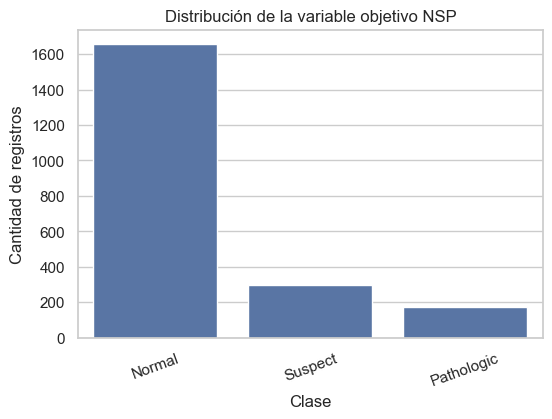

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map(CLASS_NAMES), order=list(CLASS_NAMES.values()), ax=ax)
ax.set_title('Distribución de la variable objetivo NSP')
ax.set_xlabel('Clase')
ax.set_ylabel('Cantidad de registros')
plt.xticks(rotation=20)
plt.show()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    'SVM RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf',
            class_weight='balanced',
            probability=False,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print('Train:', X_train.shape, 'Test:', X_test.shape)
display(y_train.value_counts().sort_index().rename(index=CLASS_NAMES).to_frame('train'))
display(y_test.value_counts().sort_index().rename(index=CLASS_NAMES).to_frame('test'))


Train: (1700, 21) Test: (426, 21)


,train
NSP,
Normal,1323
Suspect,236
Pathologic,141


,test
NSP,
Normal,332
Suspect,59
Pathologic,35


## 5.- Presente resultados de forma ordenada

Las tablas siguientes priorizan `F1-macro` y `recall` de la clase patológica. La exactitud (`accuracy`) se informa solo como métrica secundaria porque el dataset está desbalanceado.


In [8]:
scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'accuracy': 'accuracy',
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        'modelo': name,
        'f1_macro_cv_media': scores['test_f1_macro'].mean(),
        'f1_macro_cv_std': scores['test_f1_macro'].std(),
        'recall_macro_cv_media': scores['test_recall_macro'].mean(),
        'recall_macro_cv_std': scores['test_recall_macro'].std(),
        'accuracy_cv_media_secundaria': scores['test_accuracy'].mean(),
        'accuracy_cv_std': scores['test_accuracy'].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('f1_macro_cv_media', ascending=False)
display(cv_results.style.format({column: '{:.3f}' for column in cv_results.columns if column != 'modelo'}))


,modelo,f1_macro_cv_media,f1_macro_cv_std,recall_macro_cv_media,recall_macro_cv_std,accuracy_cv_media_secundaria,accuracy_cv_std
1,Random Forest,0.895,0.014,0.873,0.011,0.941,0.007
2,SVM RBF,0.830,0.021,0.882,0.015,0.885,0.017
0,Logistic Regression,0.778,0.037,0.851,0.038,0.863,0.021


In [9]:
fitted_models = {}
test_rows = []
predictions = {}

for name, model in models.items():
    fitted = model.fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    fitted_models[name] = fitted
    predictions[name] = y_pred
    test_rows.append({
        'modelo': name,
        'f1_macro_test': f1_score(y_test, y_pred, average='macro'),
        'recall_pathologic_clase_3': recall_score(y_test, y_pred, labels=[3], average='macro', zero_division=0),
        'precision_macro_test': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro_test': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'accuracy_test_secundaria': accuracy_score(y_test, y_pred),
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ['f1_macro_test', 'recall_pathologic_clase_3'], ascending=False
)
display(test_results.style.format({column: '{:.3f}' for column in test_results.columns if column != 'modelo'}))


,modelo,f1_macro_test,recall_pathologic_clase_3,precision_macro_test,recall_macro_test,accuracy_test_secundaria
1,Random Forest,0.877,0.886,0.914,0.850,0.934
2,SVM RBF,0.813,0.800,0.787,0.867,0.883
0,Logistic Regression,0.779,0.857,0.740,0.853,0.854


In [10]:
for name, y_pred in predictions.items():
    print('=' * 80)
    print(name)
    print(classification_report(
        y_test,
        y_pred,
        labels=[1, 2, 3],
        target_names=[CLASS_NAMES[1], CLASS_NAMES[2], CLASS_NAMES[3]],
        zero_division=0,
    ))


Logistic Regression
              precision    recall  f1-score   support

      Normal       0.99      0.86      0.92       332
     Suspect       0.52      0.85      0.64        59
  Pathologic       0.71      0.86      0.78        35

    accuracy                           0.85       426
   macro avg       0.74      0.85      0.78       426
weighted avg       0.90      0.85      0.87       426

Random Forest
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       332
     Suspect       0.89      0.68      0.77        59
  Pathologic       0.91      0.89      0.90        35

    accuracy                           0.93       426
   macro avg       0.91      0.85      0.88       426
weighted avg       0.93      0.93      0.93       426

SVM RBF
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94       332
     Suspect       0.57      0.92      0.70        59
  Pathologic       0.80      0.80

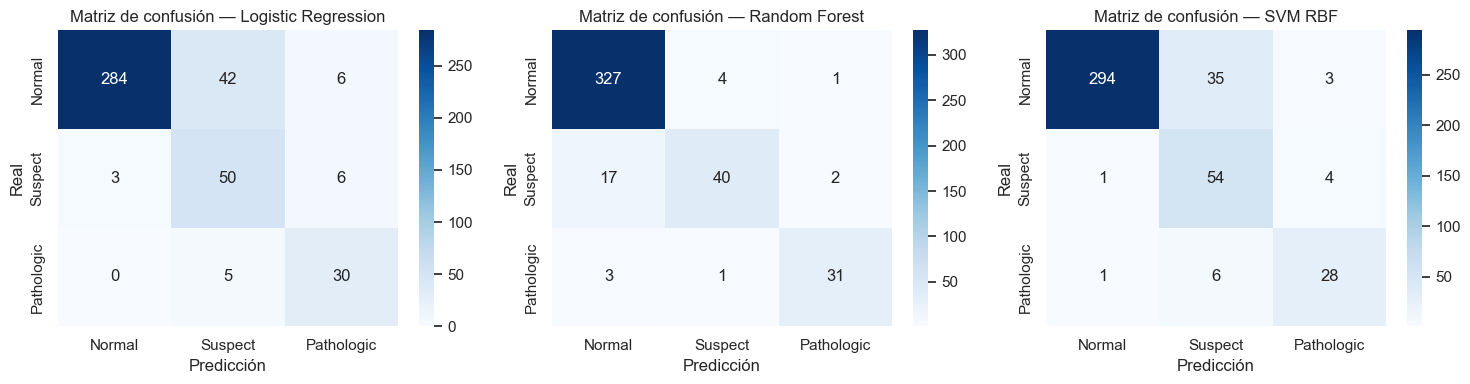

In [11]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))
if len(predictions) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[CLASS_NAMES[i] for i in [1, 2, 3]],
        yticklabels=[CLASS_NAMES[i] for i in [1, 2, 3]],
        ax=ax,
    )
    ax.set_title(f'Matriz de confusión — {name}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()


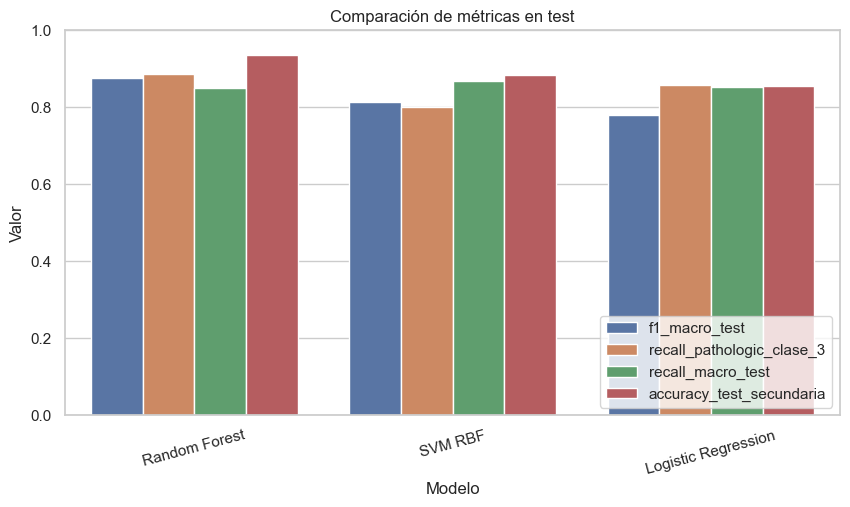

In [12]:
plot_metrics = test_results.melt(
    id_vars='modelo',
    value_vars=['f1_macro_test', 'recall_pathologic_clase_3', 'recall_macro_test', 'accuracy_test_secundaria'],
    var_name='métrica',
    value_name='valor',
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_metrics, x='modelo', y='valor', hue='métrica', ax=ax)
ax.set_title('Comparación de métricas en test')
ax.set_ylim(0, 1)
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()


In [13]:
best_model_name = test_results.iloc[0]['modelo']
best_model_metrics = test_results.iloc[0]
best_cv = cv_results[cv_results['modelo'] == best_model_name].iloc[0]

print('Resumen automático para el análisis:')
print(f"Modelo recomendado según el orden de prioridad definido: {best_model_name}")
print(f"F1-macro en test: {best_model_metrics['f1_macro_test']:.3f}")
print(f"Recall clase Pathologic (NSP=3): {best_model_metrics['recall_pathologic_clase_3']:.3f}")
print(f"Accuracy secundaria en test: {best_model_metrics['accuracy_test_secundaria']:.3f}")
print(f"F1-macro promedio en validación cruzada: {best_cv['f1_macro_cv_media']:.3f} ± {best_cv['f1_macro_cv_std']:.3f}")


Resumen automático para el análisis:
Modelo recomendado según el orden de prioridad definido: Random Forest
F1-macro en test: 0.877
Recall clase Pathologic (NSP=3): 0.886
Accuracy secundaria en test: 0.934
F1-macro promedio en validación cruzada: 0.895 ± 0.014


## 6.- Analice los resultados obtenidos

> El resumen automático anterior se generó al ejecutar el notebook localmente. La interpretación debe leerse junto con las tablas de validación cruzada, test, reportes por clase y matrices de confusión.

### Criterio de comparación

La métrica principal del experimento es `F1-macro`, porque promedia el desempeño de las tres clases sin dejar que la clase mayoritaria `Normal` domine la evaluación. Además, se revisa especialmente el `recall` de la clase `Pathologic` (`NSP=3`), ya que en un contexto clínico un falso negativo patológico es más riesgoso que una falsa alarma.

### Desbalance de clases

El dataset CTG está desbalanceado: la clase `Normal` suele concentrar la mayor parte de los registros, mientras que `Pathologic` es minoritaria. Por eso, la exactitud puede dar una impresión demasiado optimista. Un modelo que acierta muchos casos normales pero falla los patológicos no es aceptable para el objetivo planteado en los puntos 2 y 3.

### Comparación esperada entre modelos

- **Regresión Logística** funciona como baseline interpretable. Si su desempeño es competitivo, indica que existe señal lineal suficiente en las variables CTG.
- **Random Forest** suele capturar relaciones no lineales e interacciones entre variables clínicas tabulares. Debe revisarse si mejora `F1-macro` sin sacrificar el recall patológico.
- **SVM RBF** puede separar fronteras no lineales complejas, pero depende de la escala de las variables y puede ser menos interpretable.

### Modelo recomendado

El modelo recomendado se elige con este orden de prioridad:

1. Mayor `F1-macro` en validación cruzada y test.
2. Alto `recall` para la clase `Pathologic`.
3. Matriz de confusión con pocos patológicos clasificados como normales.
4. Estabilidad entre validación cruzada y test, evitando elegir un modelo que parezca bueno solo por azar en la partición final.

### Limitaciones

Este experimento usa solo las variables técnicas `LB` a `Tendency` y excluye etiquetas diagnósticas derivadas (`CLASS`, `A`–`SUSP`, `DR`) para evitar fuga de información. No reemplaza evaluación clínica real; sirve como comparación reproducible de modelos de clasificación sobre el dataset CTG.


## 7.- Entrega GitHub / Colab

La entrega final debe ser un enlace al repositorio GitHub que contenga:

- `CTG.xls` en la raíz del proyecto.
- Este notebook en `notebooks/ctg_nsp_experiment.ipynb`.
- `requirements.txt` con las dependencias necesarias.
- `README.md` con instrucciones para ejecución local o en Colab.

Para una ejecución más rápida, se puede abrir este notebook en Google Colab, subir `CTG.xls` si hace falta y ejecutar todas las celdas desde arriba hacia abajo.
